### *Final project*

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

red = pd.read_csv("winequality-red.csv", sep=";")
white = pd.read_csv("winequality-white.csv", sep=";")

red["wine_type"] = "red"
white["wine_type"] = "white"

df = pd.concat([red, white], ignore_index=True)


df = pd.concat([red, white], ignore_index=True)
numeric_cols = df.select_dtypes(include=np.number).columns

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

print("\nMissing values:")
print(df.isnull().sum())

print("\nSummary statistics:")
print(df.describe())

Shape: (6497, 13)

Columns:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality', 'wine_type']

First 5 rows:
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65

### ***UNIVARIATE ANALYSIS***

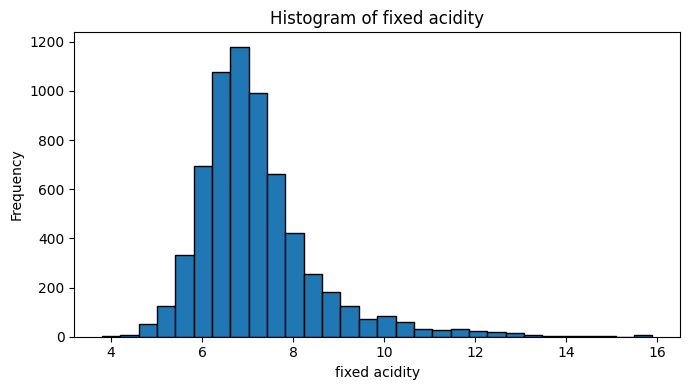

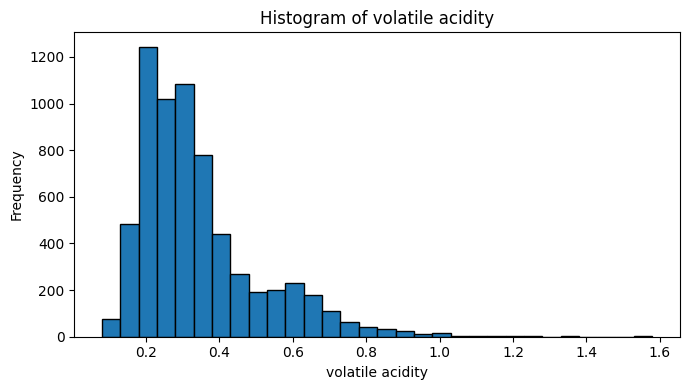

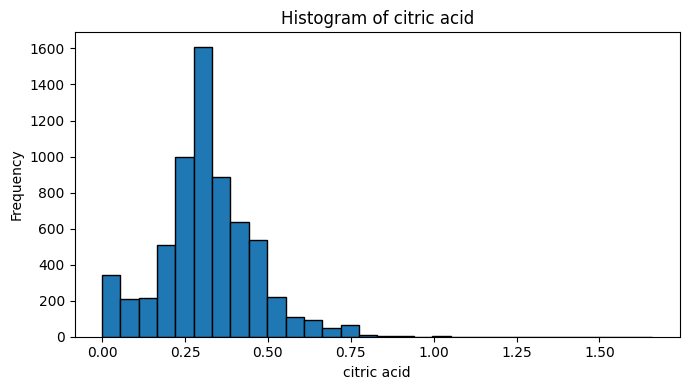

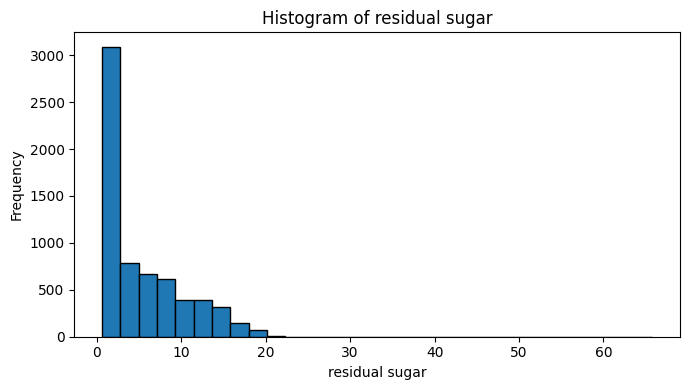

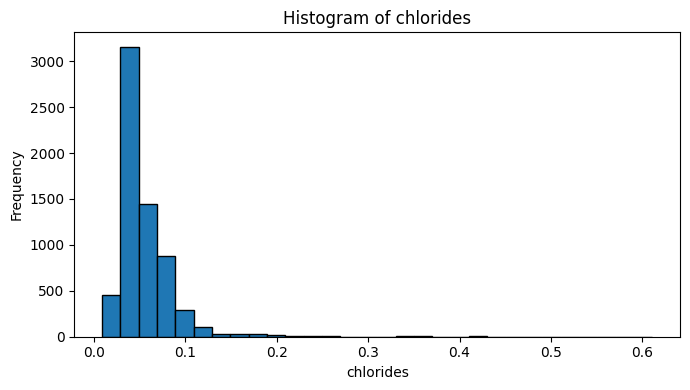

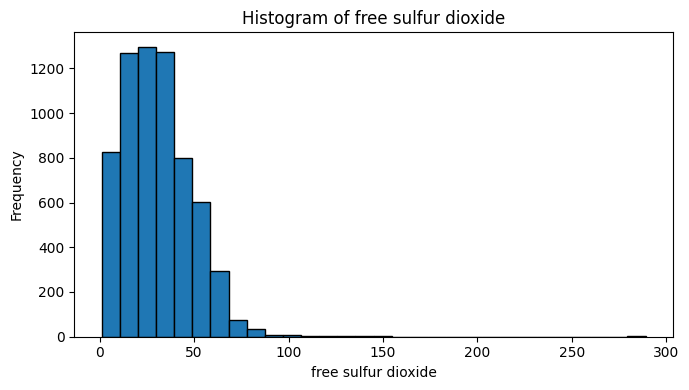

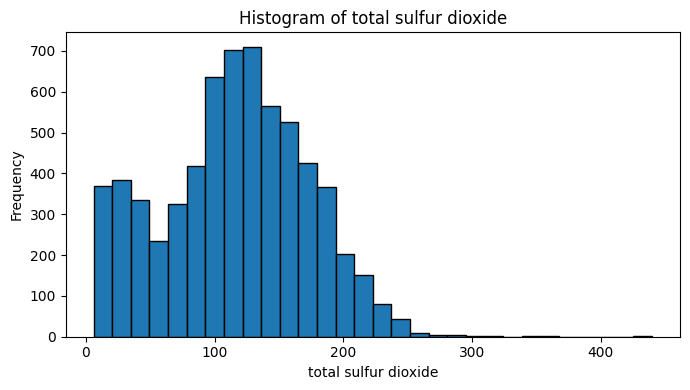

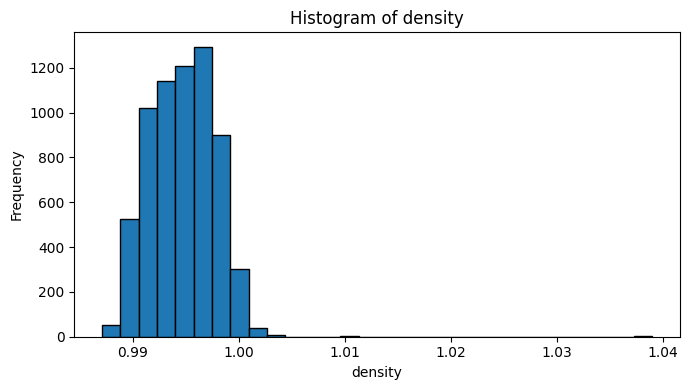

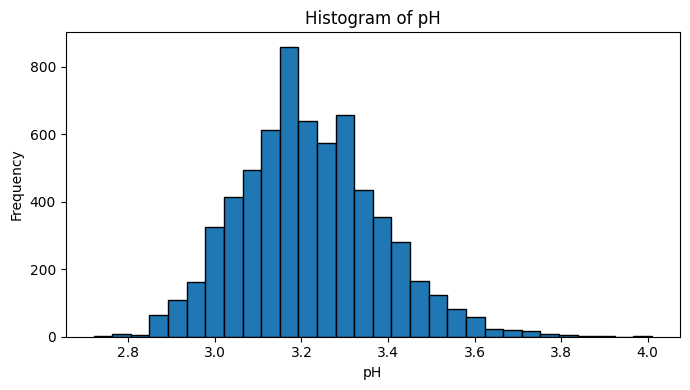

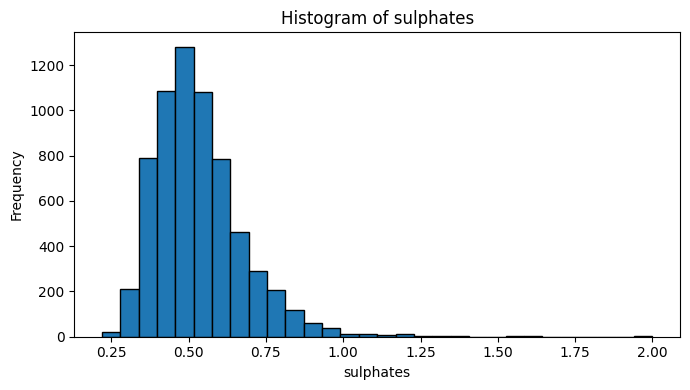

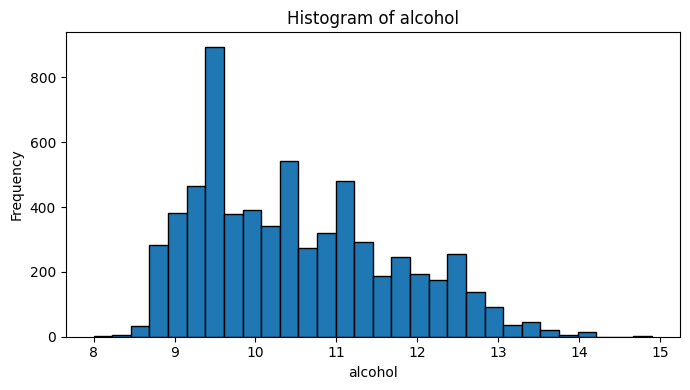

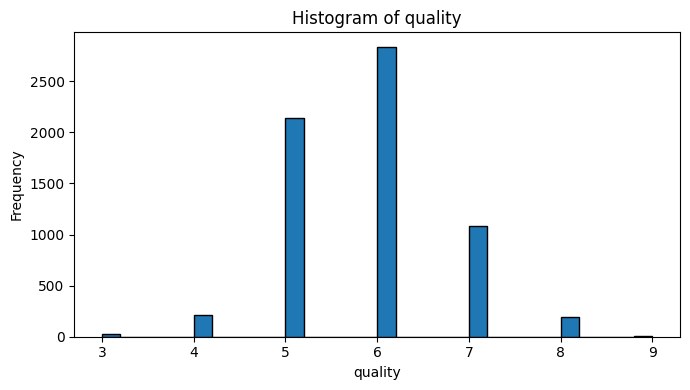

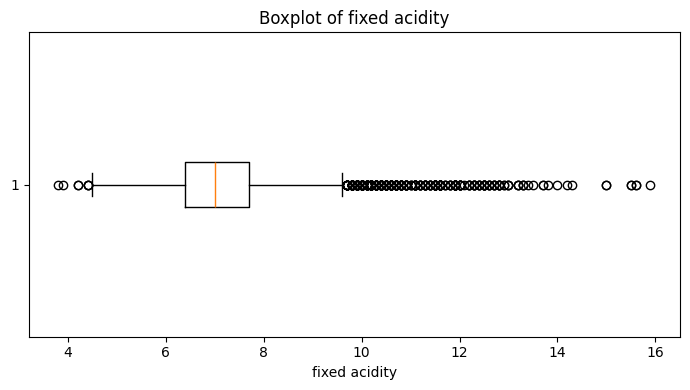

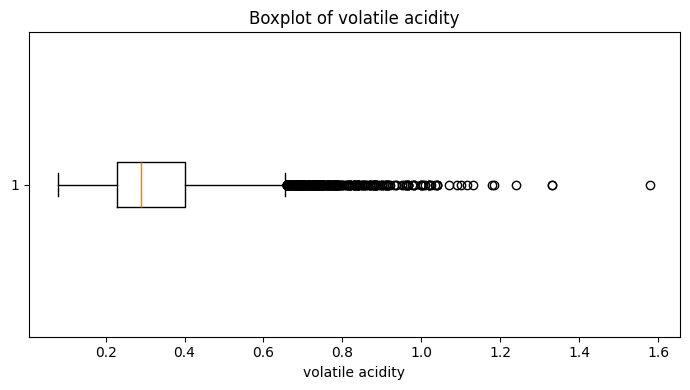

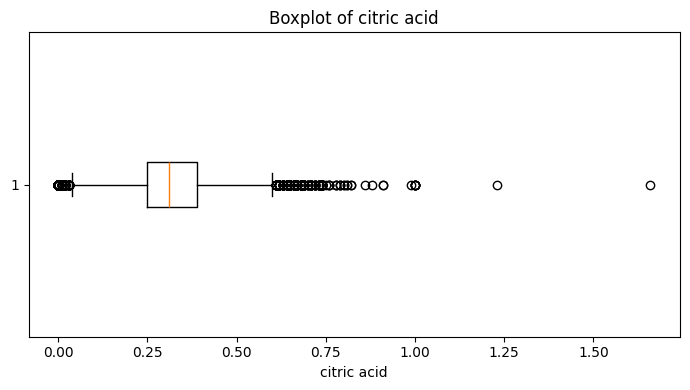

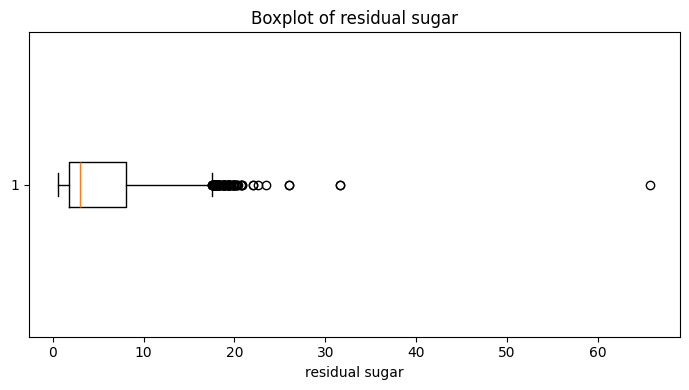

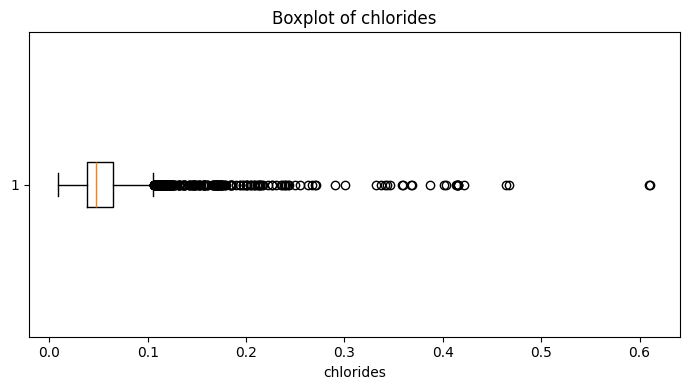

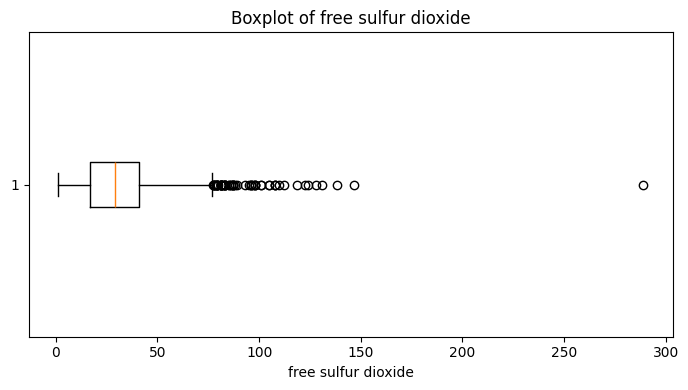

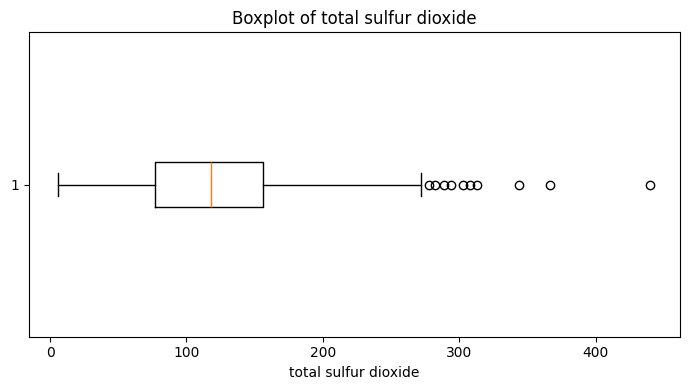

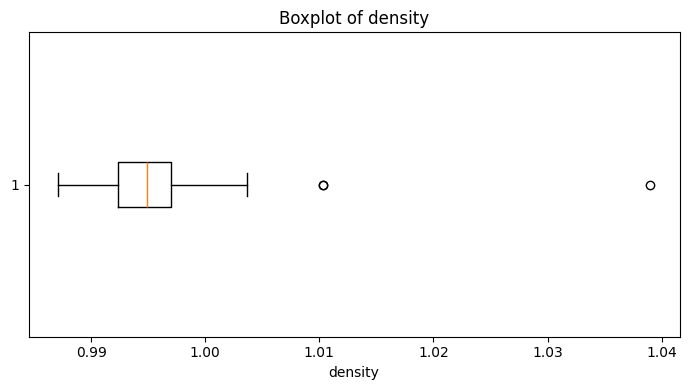

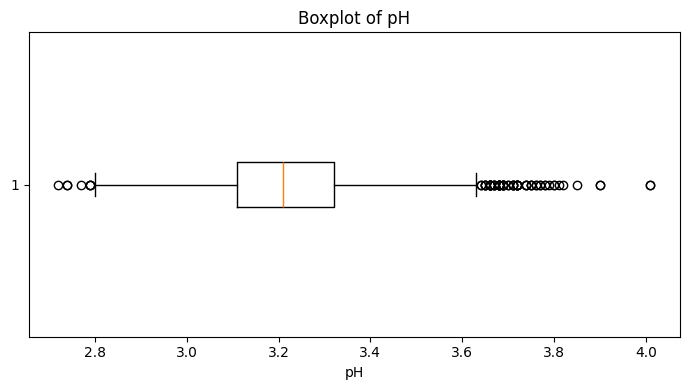

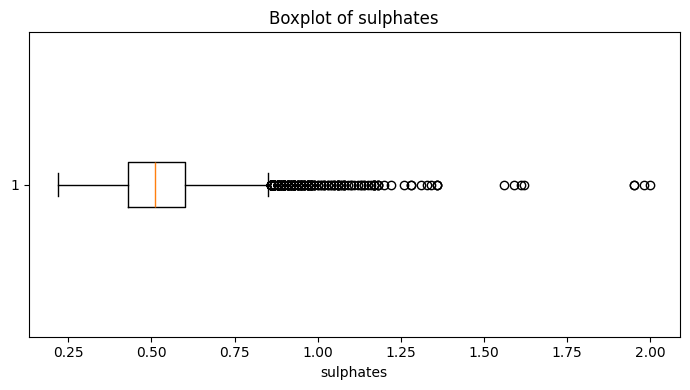

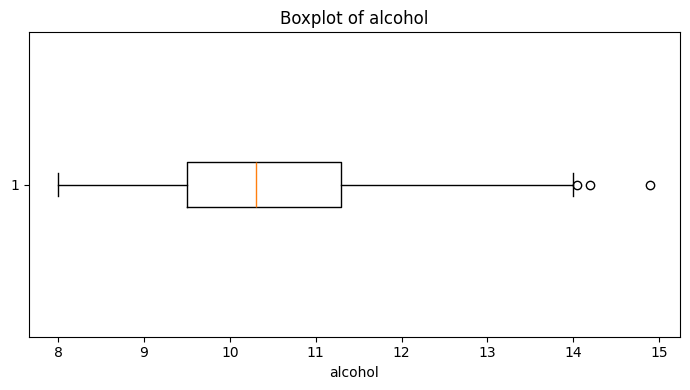

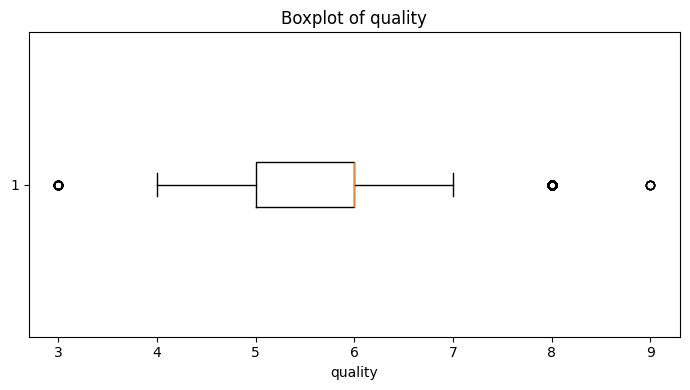

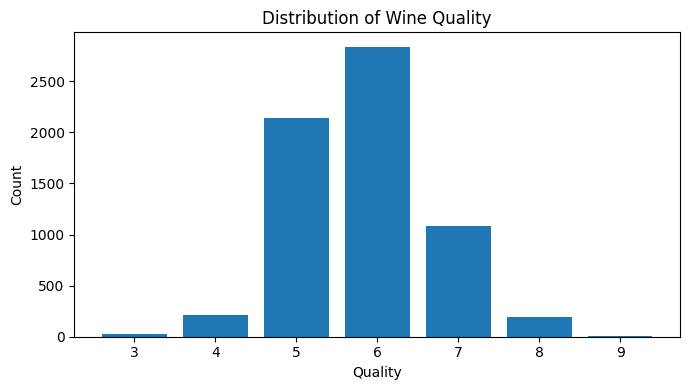

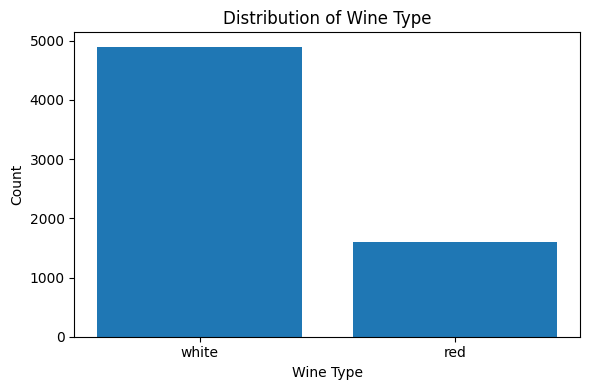

In [10]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    plt.hist(df[col], bins=30, edgecolor="black")
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    plt.boxplot(df[col], vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

# Quality count plot
quality_counts = df["quality"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
plt.bar(quality_counts.index.astype(str), quality_counts.values)
plt.title("Distribution of Wine Quality")
plt.xlabel("Quality")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# Wine type count plot
type_counts = df["wine_type"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(type_counts.index, type_counts.values)
plt.title("Distribution of Wine Type")
plt.xlabel("Wine Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


Fixed Acidity

Most wines have similar acidity (around 6–7). A few wines have higher acidity, but they are rare.

Volatile Acidity

Most wines have low volatile acidity, which is good quality. High values are rare and may indicate defects.

Citric Acid

Most wines contain a moderate amount of citric acid. Very low or very high values are uncommon.

Residual Sugar

Most wines are dry (low sugar). Only a few wines are very sweet.

Chlorides

Most wines have low salt content. A few wines have higher levels, which may affect taste.

Free Sulfur Dioxide

Most wines have moderate preservative levels. Some wines have very high values, but they are uncommon.

Total Sulfur Dioxide

Values vary a lot between wines. Most are in a medium range, but some wines contain very high amounts.

 Density

Density is very similar for most wines. This shows consistency in composition.

 pH

pH values are stable around 3.2. This means most wines have a similar acidity level.

Sulphates

Most wines have moderate sulphates. High values are rare but present.

Alcohol

Alcohol levels vary more than other features. Most wines are between 9% and 12%, but some are stronger.

Wine Quality

Most wines are average quality (5–7). Very high or very low quality wines are rare.

Wine Type

There are many more white wines than red wines, so the dataset is not balanced.

SABINA COMMENT: You also need to write your thoughts on these charts. What information can you extract from them?

### ***CORRELATION MATRIX***

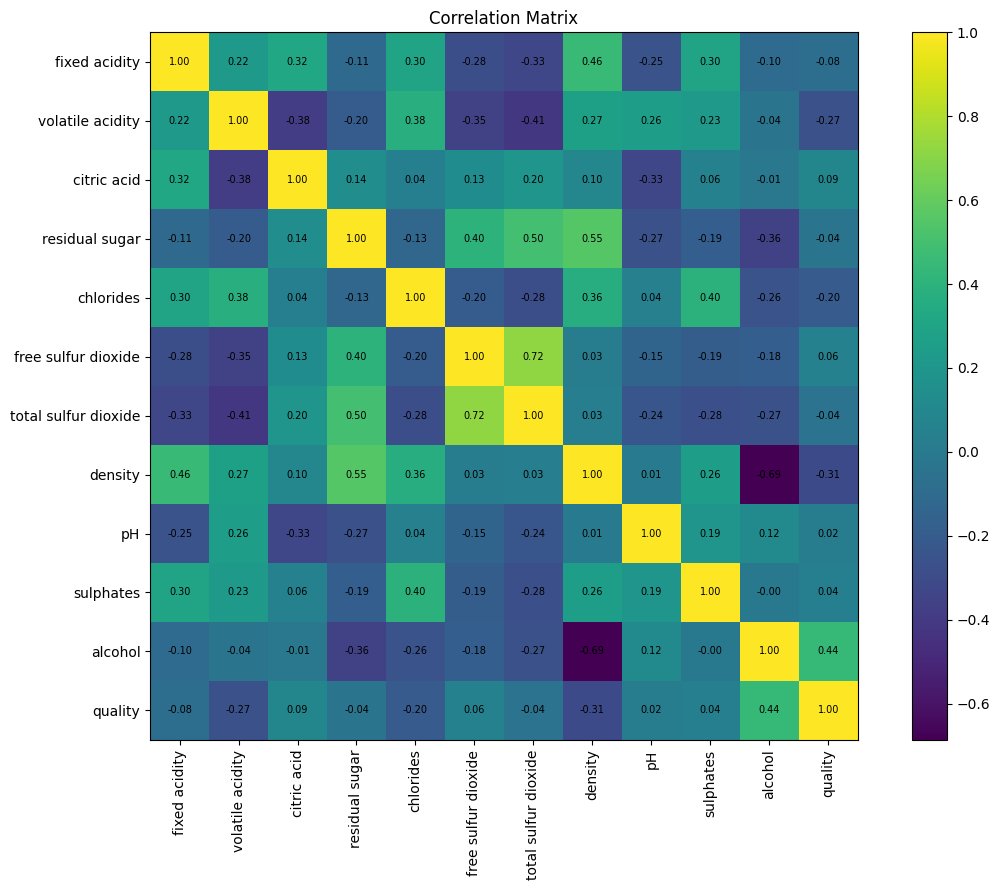

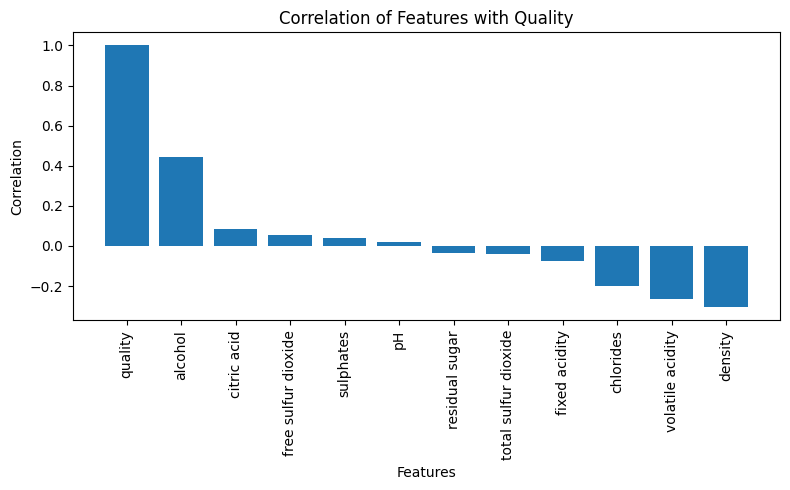


Correlation with quality:
quality                 1.000000
alcohol                 0.444319
citric acid             0.085532
free sulfur dioxide     0.055463
sulphates               0.038485
pH                      0.019506
residual sugar         -0.036980
total sulfur dioxide   -0.041385
fixed acidity          -0.076743
chlorides              -0.200666
volatile acidity       -0.265699
density                -0.305858
Name: quality, dtype: float64


In [11]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
plt.imshow(corr, interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

quality_corr = corr["quality"].sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(quality_corr.index, quality_corr.values)
plt.title("Correlation of Features with Quality")
plt.xlabel("Features")
plt.ylabel("Correlation")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("\nCorrelation with quality:")
print(quality_corr)

Correlation Matrix
Most variables have weak to moderate correlations, meaning no single factor fully explains wine quality.
Alcohol has a positive correlation with quality → higher alcohol wines tend to be better.
Density has a strong negative correlation with alcohol (-0.69) → when alcohol increases, density decreases.
Free and total sulfur dioxide are strongly correlated (0.72) → they are closely related.
Residual sugar is positively correlated with density (0.55) → sweeter wines are denser.

Correlation with Quality 
Alcohol has the strongest positive impact on quality (~0.44) → most important factor.
Citric acid, sulphates, and free sulfur dioxide have small positive effects.
Volatile acidity has a negative correlation (~ -0.27) → higher volatile acidity lowers quality.
Density also negatively affects quality (~ -0.31).
Other variables have very weak influence.

SABINA COMMENT: Same with the correlation matrix. What are the main insights here?

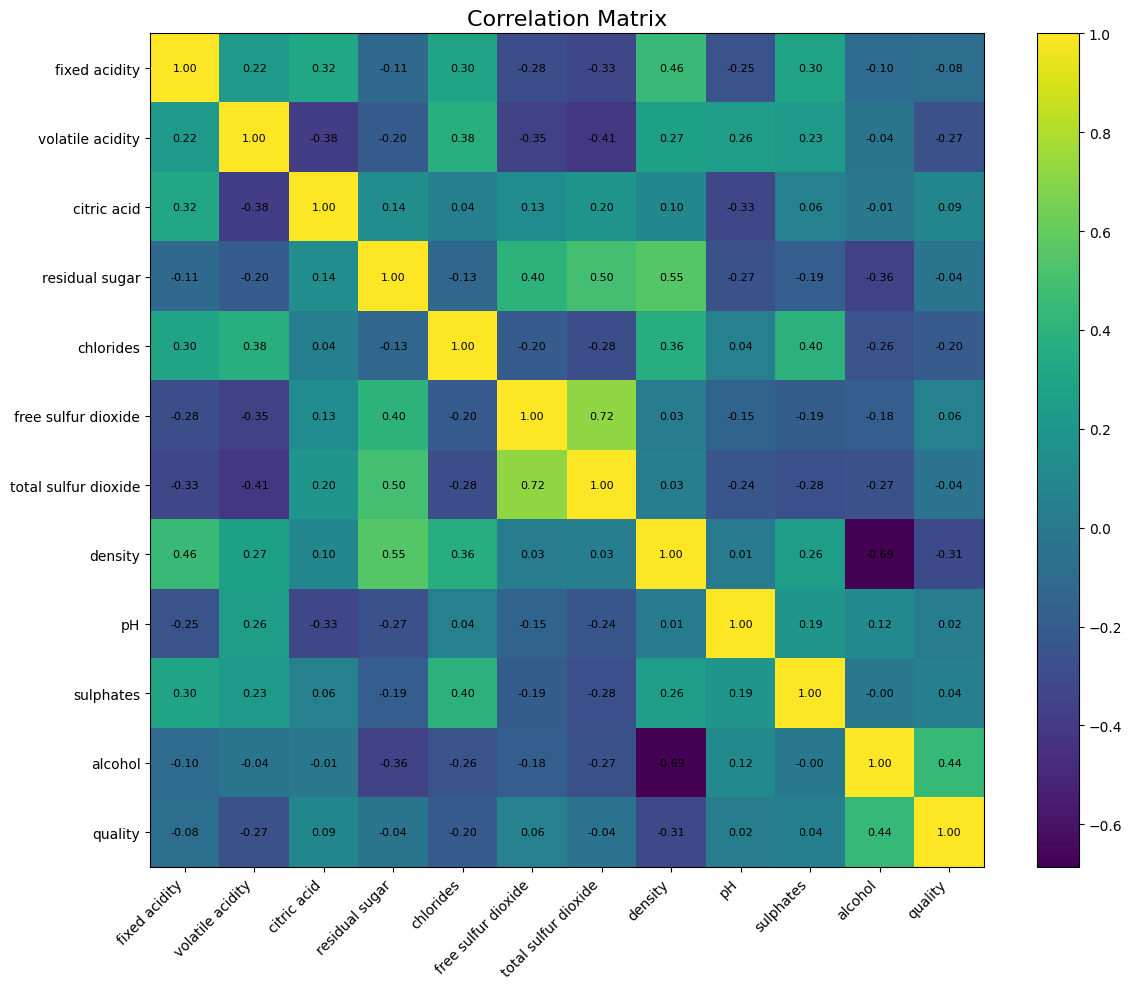

In [12]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(14, 10))
im = plt.imshow(corr, interpolation="nearest")
plt.colorbar(im, fraction=0.046, pad=0.04)

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8, color="black")

plt.title("Correlation Matrix", fontsize=16)
plt.tight_layout()
plt.show()

### ***BIVARIATE ANALYSIS***

<Figure size 800x500 with 0 Axes>

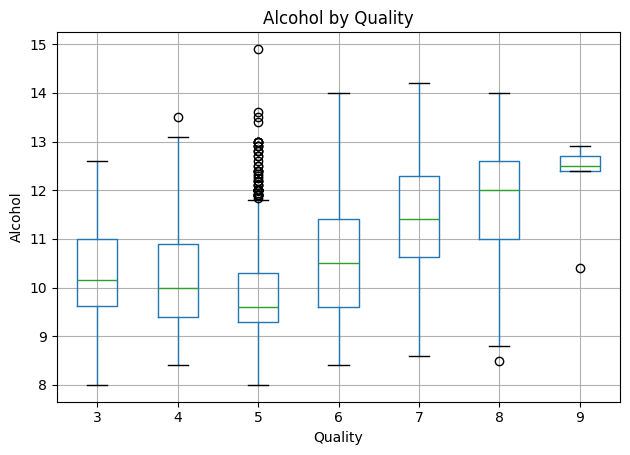

<Figure size 800x500 with 0 Axes>

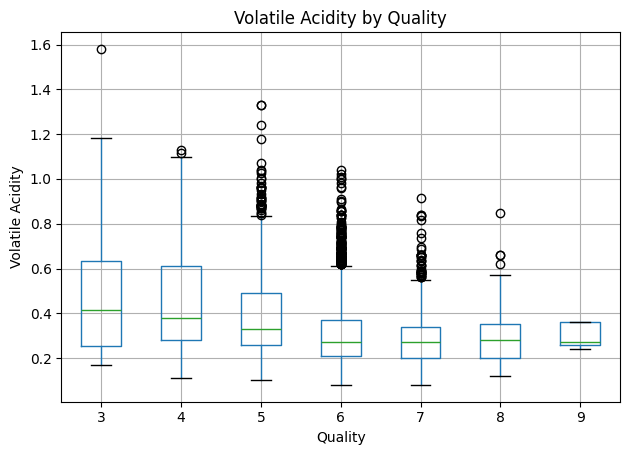

<Figure size 800x500 with 0 Axes>

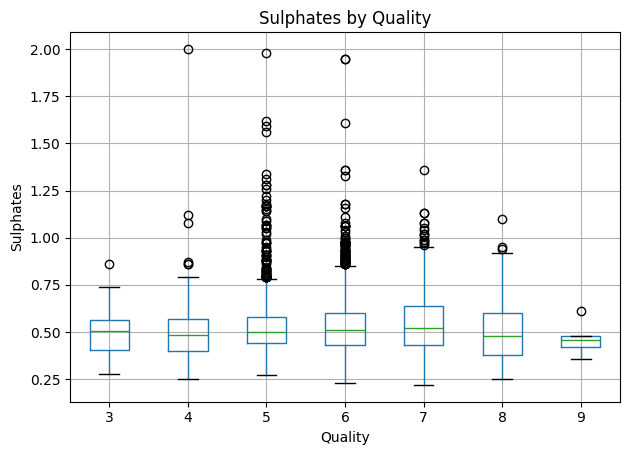

<Figure size 800x500 with 0 Axes>

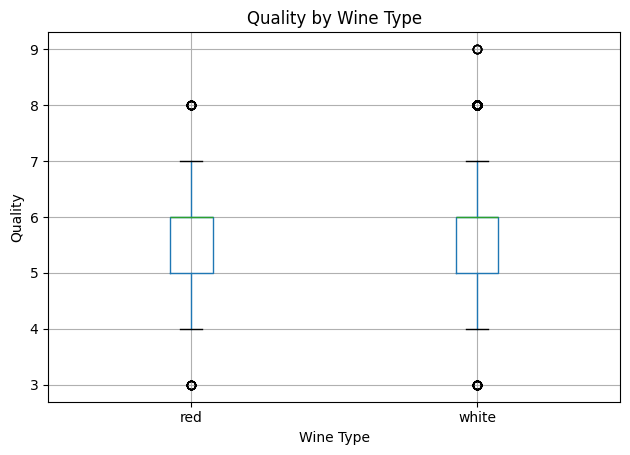

<Figure size 800x500 with 0 Axes>

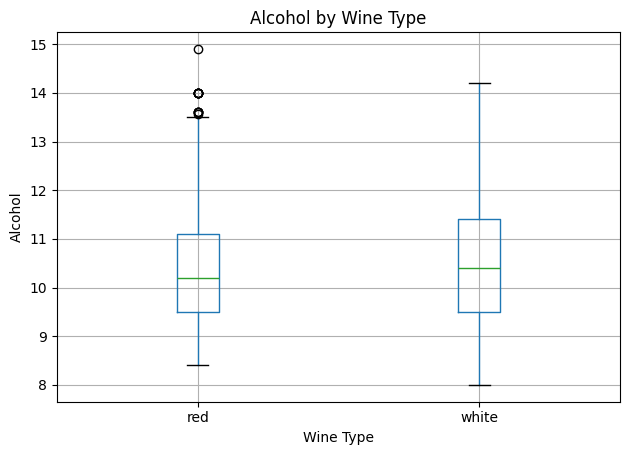

<Figure size 800x500 with 0 Axes>

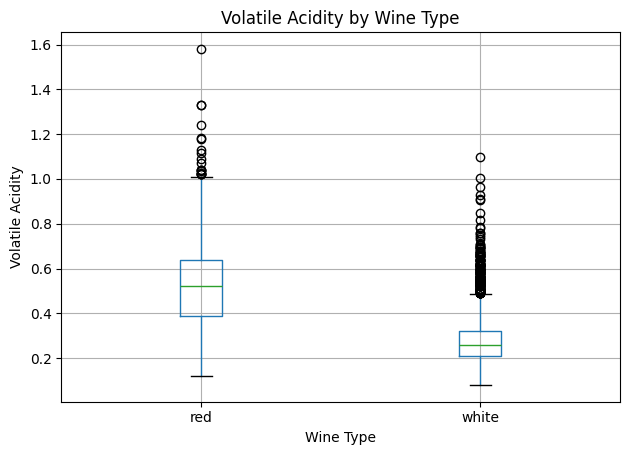

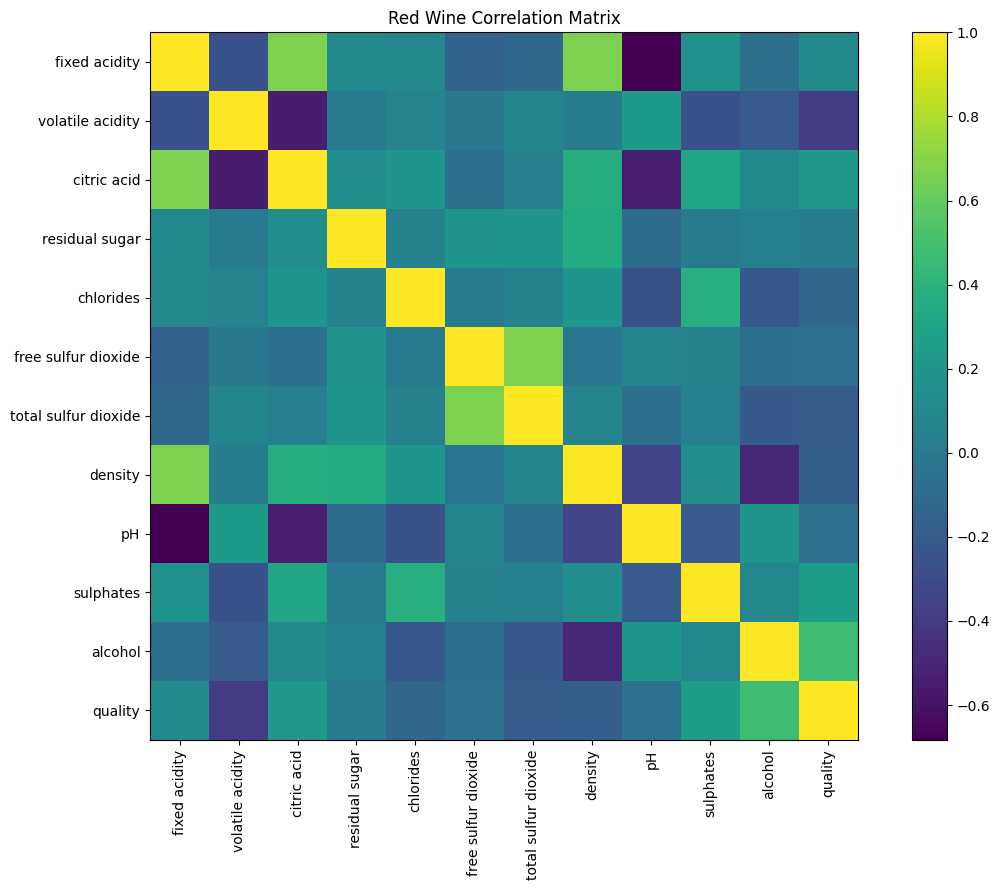

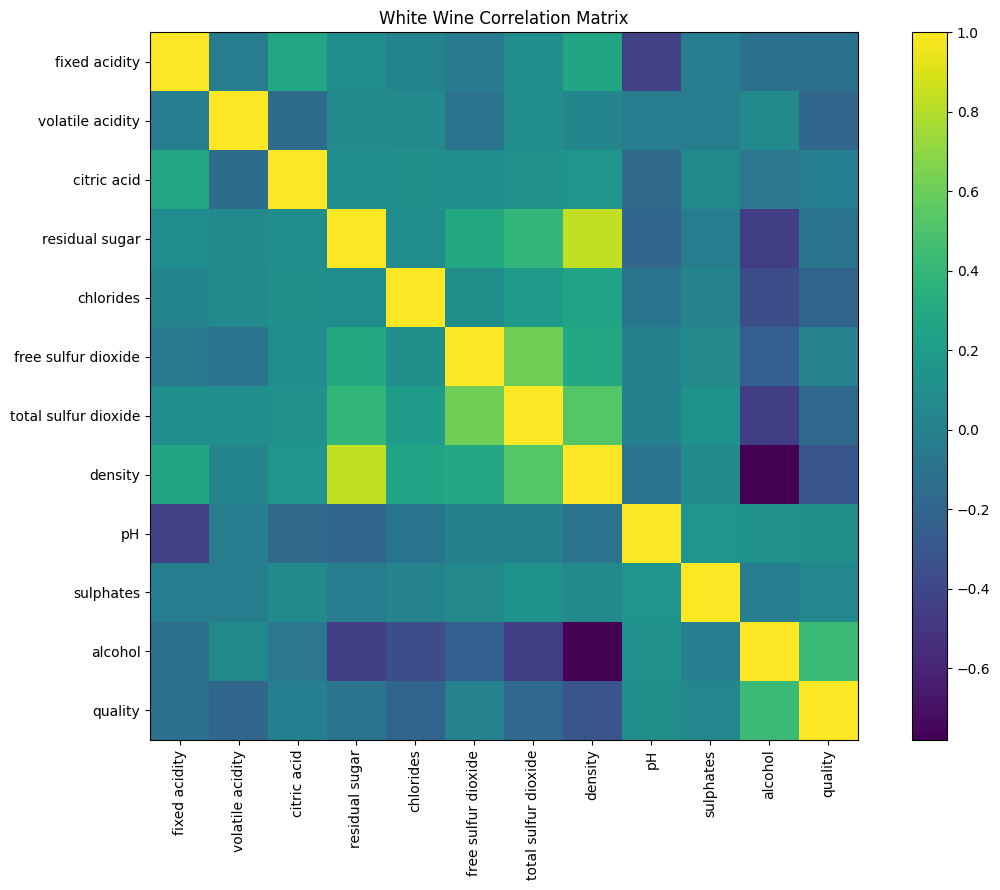

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

red = pd.read_csv("winequality-red.csv", sep=";")
white = pd.read_csv("winequality-white.csv", sep=";")

red["wine_type"] = "red"
white["wine_type"] = "white"

df = pd.concat([red, white], ignore_index=True)
plt.figure(figsize=(8, 5))
df.boxplot(column="alcohol", by="quality")
plt.title("Alcohol by Quality")
plt.suptitle("")
plt.xlabel("Quality")
plt.ylabel("Alcohol")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
df.boxplot(column="volatile acidity", by="quality")
plt.title("Volatile Acidity by Quality")
plt.suptitle("")
plt.xlabel("Quality")
plt.ylabel("Volatile Acidity")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
df.boxplot(column="sulphates", by="quality")
plt.title("Sulphates by Quality")
plt.suptitle("")
plt.xlabel("Quality")
plt.ylabel("Sulphates")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
df.boxplot(column="quality", by="wine_type")
plt.title("Quality by Wine Type")
plt.suptitle("")
plt.xlabel("Wine Type")
plt.ylabel("Quality")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
df.boxplot(column="alcohol", by="wine_type")
plt.title("Alcohol by Wine Type")
plt.suptitle("")
plt.xlabel("Wine Type")
plt.ylabel("Alcohol")
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
df.boxplot(column="volatile acidity", by="wine_type")
plt.title("Volatile Acidity by Wine Type")
plt.suptitle("")
plt.xlabel("Wine Type")
plt.ylabel("Volatile Acidity")
plt.tight_layout()
plt.show()

# =========================
# OPTIONAL: RED AND WHITE SEPARATE CORRELATIONS
# =========================
red_corr = red.drop(columns=["wine_type"]).corr()
white_corr = white.drop(columns=["wine_type"]).corr()

plt.figure(figsize=(12, 9))
plt.imshow(red_corr, interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(red_corr.columns)), red_corr.columns, rotation=90)
plt.yticks(range(len(red_corr.columns)), red_corr.columns)
plt.title("Red Wine Correlation Matrix")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 9))
plt.imshow(white_corr, interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(white_corr.columns)), white_corr.columns, rotation=90)
plt.yticks(range(len(white_corr.columns)), white_corr.columns)
plt.title("White Wine Correlation Matrix")
plt.tight_layout()
plt.show()

SABINA COMMENT: We shouldn't be doing scatterplots when looking at numerical discrete + numerical continuous features. Here the boxplots were the only accurate choice.

Also, where are the conclusions???

Conclusions from the boxplots

Alcohol by Quality
The boxplot shows that wines with higher quality generally have higher alcohol levels. This suggests a positive relationship between alcohol and wine quality.

Volatile Acidity by Quality
Higher-quality wines tend to have lower volatile acidity. This indicates that volatile acidity negatively affects wine quality.

Sulphates by Quality
Wines with better quality usually have slightly higher sulphate levels. The relationship is not very strong, but there is a positive tendency.

Quality by Wine Type
White and red wines do not have exactly the same quality distribution. One type may show a slightly higher median or different spread, which means wine type can influence quality patterns.

Alcohol by Wine Type
The alcohol content is not distributed in the same way for red and white wines. This shows that wine type is associated with different alcohol characteristics.

Volatile Acidity by Wine Type
Red and white wines show different distributions of volatile acidity, meaning that this feature varies depending on wine type.

### ***Multiclass Prediction***

In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [ ]:
red = pd.read_csv("winequality-red.csv", sep=";")
white = pd.read_csv("winequality-white.csv", sep=";") 
red["wine_type"] = "red"
white["wine_type"] = "white"

df = pd.concat([red, white], ignore_index=True)

wine_type_encoder = LabelEncoder()
df["wine_type"] = wine_type_encoder.fit_transform(df["wine_type"])

X = df.drop("quality", axis=1)
y = df["quality"]

# SABINA COMMENT: Why choose 20% for the test set?
# Also, I would be careful about the train-test split here - what will happen if you have
# 90% white wines in the train set and 50% white wines in the test set?
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# SABINA COMMENT: Why are we using a label encoder here?
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_test_encoded = label_encoder.transform(y_test)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Classes:", sorted(y.unique()))
print(df.head())

Train shape: (5197, 12)
Test shape: (1300, 12)
Classes: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4            

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

# SABINA COMMENT: Any reason we are using a try-except here?
try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    xgb_available = False

models = {
    # SABINA COMMENT: When looking at baseline models, we'd typically go with the
    # default settings (except for the random_state, which we'd want to set)
    # Any reason you fixed the n_estimators here?
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=150, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
}

if xgb_available:
    models["XGBoost"] = XGBClassifier(
        objective="multi:softprob",
        num_class=len(np.unique(y_train_encoded)),
        eval_metric="mlogloss",
        random_state=42
    )

results = []
best_model = None
best_model_name = None
best_f1 = -1

for name, model in models.items():
    print(f"\n{'='*60}")
    print(f"MODEL: {name}")
    print(f"{'='*60}")

    if name == "XGBoost":
        # SABINA COMMENT: Why are we doing something different for XGBoost?
        model.fit(X_train_scaled, y_train_encoded)
        y_pred_encoded = model.predict(X_test_scaled)
        y_pred = label_encoder.inverse_transform(y_pred_encoded.astype(int))
    else:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average="weighted")

    print("Accuracy:", round(acc, 4))
    print("Weighted F1:", round(f1, 4))
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Weighted_F1": f1
    })

    if f1 > best_f1:
        best_f1 = f1
        best_model = model
        best_model_name = name

results_df = pd.DataFrame(results).sort_values(by="Weighted_F1", ascending=False)

print("\nBest Model:", best_model_name)
print(results_df)


MODEL: Decision Tree
Accuracy: 0.5938
Weighted F1: 0.593

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         6
           4       0.16      0.12      0.13        43
           5       0.66      0.64      0.65       428
           6       0.64      0.63      0.63       567
           7       0.50      0.56      0.53       216
           8       0.31      0.38      0.34        39
           9       0.00      0.00      0.00         1

    accuracy                           0.59      1300
   macro avg       0.32      0.33      0.33      1300
weighted avg       0.59      0.59      0.59      1300

Confusion Matrix:
[[  0   0   3   3   0   0   0]
 [  0   5  18  15   5   0   0]
 [  3  18 274 105  24   4   0]
 [  1   9 106 358  77  16   0]
 [  0   0  14  69 120  13   0]
 [  0   0   0  13  11  15   0]
 [  0   0   0   0   1   0   0]]

MODEL: Random Forest
Accuracy: 0.6931
Weighted F1: 0.6812

Classification Report:
  

In [10]:
results_df = pd.DataFrame(results).sort_values(by="Weighted_F1", ascending=False)
results_df.to_csv("model_results.csv", index=False)
print(results_df)

               Model  Accuracy  Weighted_F1
1      Random Forest  0.693077     0.681187
4            XGBoost  0.666154     0.659145
0      Decision Tree  0.593846     0.592969
3  Gradient Boosting  0.583846     0.570599
2           AdaBoost  0.476154     0.457018


In [9]:
import joblib

joblib.dump(best_model, "best_wine_model.pkl")
joblib.dump(scaler, "wine_scaler.pkl")
joblib.dump(X.columns.tolist(), "wine_feature_names.pkl")
results_df.to_csv("model_results.csv", index=False)

print("Files saved successfully.")

Files saved successfully.
